**This problem set is due Wednesday, September 16, 2026 at 11:59 pm. Please plan ahead and submit your work on time.**

### Problem Set 01: Uninformed Search

In this Problem Set you will implement Breadth First Search and Depth First Search and use them to solve the [8 Puzzle Problem](https://en.wikipedia.org/wiki/15_puzzle).

0. [Credit for Contributors (required)](#contributors)
1. [State Representation in the 8 Puzzle Problem (35 points)](#state_representation)
    1. [Successor Function (25 points)](#state_expansion)
    2. [Completing the `PuzzleProblem` class (10 points)](#puzzle_problem_class)
2. [Simple Search (52 points)](#simple_search)
    1. [Breadth First Search (27 points)](#bfs_implementation)
    2. [Depth First Search (25 points)](#dfs_implementation)
3. [Differences Between BFS and DFS (8 points)](#ai_component)
    1. [Using an LLM to Find a Differentiating Example [AI-enabled] (4 points)](#llm_differentiating_example)
    2. [Visualize the Domain [AI-enabled] (4 points)](#visualize_domain)
4. [Time Spent on Pset (5 points)](#time_spent)

**100 points** total for Problem Set 1

## <a name="contributors"></a> Credit for Contributors

List the various students, lecture notes, or online resouces that helped you complete this problem set:

Ex: I worked with Bob on the cat activity planning problem.

<div class="alert alert-info">
Write your answer in the cell below this one.
</div>

- Lecture 1 and 2 Slide
- This page on tuples: https://www.w3schools.com/python/python_tuples_update.asp

Import the modules needed for this exercise (make sure you execute the cell below by clicking on it and pressing Shift-Enter)

**Do not import any other modules**

In [1]:
%load_ext autoreload
%autoreload 2
from search_classes import SearchNode, Path
from principles_of_autonomy.grader import Grader
from principles_of_autonomy.notebook_tests.pset_1 import TestPSet1
import networkx
import matplotlib.pyplot as plt

## <a name="state_representation"></a>Problem 1: State Representation in the 8 Puzzle Problem

The puzzle consists of a 3x3 grid with 8 numbered tiles and a missing tile. The objective is to slide the tiles around until all the numbered tiles are ordered and the missing tile stays at the lower right cell of the grid.

<img src="puzzle8.png"/>

To make things simple, we are giving you a possible state representation for the 8-puzzle problem.

We'll represent a given state of the puzzle by a tuple of three internal tuples. Each internal tuple represents a row of the puzzle. The missing tile is represented by $0$.

For example, the puzzle state below:

<img src="example_state.png"/>

is represented by `((1, 2, 3), (8, 0, 4), (7, 6, 5))`.

Below, we are giving you some code to print a puzzle state:


In [2]:
def print_state(state):
    print("+"+ "-"*5+"+")
    for l in state:
        print("|"+ " ".join([str(el) if el!=0 else " " for el in l]) +"|")
    print("+"+ "-"*5+"+")

example_state = ((1, 2, 3), (8, 0, 4), (7, 6, 5))

print("%s state represents puzzle state: " % (example_state,))
print_state(example_state)

((1, 2, 3), (8, 0, 4), (7, 6, 5)) state represents puzzle state: 
+-----+
|1 2 3|
|8   4|
|7 6 5|
+-----+


### <a name="state_expansion"></a>1.A Successor Function (25 points)

In order to find a solution to the search problem, we need to define the states we can reach from a given state. This corresponds to the possible moves of the missing tile (at most up, down, left and right).

Implement the function `expand_state(state)` that returns a `list` of the states that can be reached from the given `state`.

For example, for state `((0, 1, 3), (4, 2, 5), (7, 8, 6))`, the function `expand_state` should return the following list (two moves are feasible):

```
[((4, 1, 3), (0, 2, 5), (7, 8, 6)), ((1, 0, 3), (4, 2, 5), (7, 8, 6))]
```

The neighbour states of state:

```
+-----+
|  1 3|
|4 2 5|
|7 8 6|
+-----+
```

are:

```
+-----+
|4 1 3|
|  2 5|
|7 8 6|
+-----+
***
+-----+
|1   3|
|4 2 5|
|7 8 6|
+-----+
```

<div class="alert alert-info">
Implement the function `expand_state(state)` below.
</div>


In [9]:
def copy_state(states):
    rows = ()
    for row in states:
        new_row = []
        print(row)
        for val in states[row]:
            new_row.append(val)

        rows.append(new_row)
    return rows

In [35]:
# Return a tuple with two positions swapped in a given matrix
def swap_positions(matrix, row, col, orow, ocol):
    # Convert the tuple of tuples into an array of arrays for mutability
    matrix_arr = []
    for matrix_row in matrix:
        matrix_arr.append(list(matrix_row))

    # Swap
    # print(f"Swapping {row}, {col} for {orow}, {ocol}")
    matrix_arr[row][col] = matrix[orow][ocol]
    matrix_arr[orow][ocol] = matrix[row][col]

    # Convert back to tuple
    matrix_tuples = []
    for matrix_row in matrix_arr:
        matrix_tuples.append(tuple(matrix_row))

    return tuple(matrix_tuples)

In [36]:
def expand_state(state):
    # Find the position (row, column) of the zero value
    position = (-1, -1)
    for row in range(len(state)):
        for col in range(len(state[0])):
            if state[row][col] == 0:
                position = (row, col)

    if position == (-1, -1):
        raise Exception("0 value not found in state matrix")

    

    
    
    states = []
    row = position[0]
    col = position[1]
    # North
    if row > 0:
        states.append(swap_positions(state, row - 1, col, row, col))
    # East
    if col < len(state[0]) - 1:
        states.append(swap_positions(state, row, col + 1, row, col))
    # South
    if row < len(state) - 1:
        states.append(swap_positions(state, row + 1, col, row, col))
    # West
    if col > 0:
        states.append(swap_positions(state, row, col - 1, row, col))
                
            
    return states

In [37]:
expand_state(((1, 2, 3), (8, 0, 4), (7, 6, 5)))

[((1, 0, 3), (8, 2, 4), (7, 6, 5)),
 ((1, 2, 3), (8, 4, 0), (7, 6, 5)),
 ((1, 2, 3), (8, 6, 4), (7, 0, 5)),
 ((1, 2, 3), (0, 8, 4), (7, 6, 5))]

In [38]:
Grader.run_single_test_inline(TestPSet1, "test_1_check_expanded_states", locals())

.
----------------------------------------------------------------------
Ran 1 test in 0.000s

OK


### <a name="puzzle_problem_class"></a> 1.B Completing the `PuzzleProblem` class (10 points)

We are giving you the class `SearchNode` defined in `search_classes.py`. This class represents a search node in the search tree. You can create a `SearchNode` by giving it the state it represents and its `SearchNode` parent (or None if it's the root element in the tree). Below is an example of the `SearchNode` class being used:

In [39]:
# Execute this example code
root_node = SearchNode(((0, 1, 3), (4, 2, 5), (7, 8, 6)), parent_node=None)
children_node = SearchNode(((4, 1, 3), (0, 2, 5), (7, 8, 6)),
                            parent_node=root_node)
print("Root node: %s" % root_node)
print("Children node: %s" % children_node)

Root node: <SearchNode: state: ((0, 1, 3), (4, 2, 5), (7, 8, 6)), parent: None>
Children node: <SearchNode: state: ((4, 1, 3), (0, 2, 5), (7, 8, 6)), parent: <SearchNode: state: ((0, 1, 3), (4, 2, 5), (7, 8, 6)), parent: None>>


We also give you the `Path` class, that takes a `SearchNode` and computes the state path from the initial state in the root of the tree to the state of the given `SearchNode`:

In [40]:
# Execute this example code
example_path = Path(children_node)
print("Path of %d states is: %s" % (len(example_path.path), example_path.path))

Path of 2 states is: [((0, 1, 3), (4, 2, 5), (7, 8, 6)), ((4, 1, 3), (0, 2, 5), (7, 8, 6))]


Implement the function `expand_node(self, search_node)` inside the `PuzzleProblem` class. The function should return a `list` of the successor SearchNodes that can be reached from the given `search_node`.


<div class="alert alert-warning">
You will want to look at the `SearchNode` and `Path` definitions in the included `search_classes.py` file, as you will need to know what useful properties you can use for the next questions.
</div>

<div class="alert alert-info">
Implement the function `expand_node(self, search_node)` below.
</div>

In [47]:
class PuzzleProblem(object):
    """Class that represents the puzzle search problem."""
    def __init__(self, start, goal):
        self.start = start
        self.goal = goal
    def test_goal(self, state):
        return self.goal == state
    def expand_node(self, search_node):
        """Return a list of SearchNodes, having the correct state and parent node."""
        nodes = []
        for possible_state in expand_state(search_node.state):
            nodes.append(SearchNode(possible_state, parent_node=search_node))
        return nodes
        raise NotImplementedError()

In [48]:
Grader.run_single_test_inline(TestPSet1, "test_2_puzzle_problem_expanded_nodes", locals())

.
----------------------------------------------------------------------
Ran 1 test in 0.000s

OK


## <a name="simple_search"></a>Problem 2: Simple Search

Now you will implement Simple Search, as seen in class, to solve the 8 Puzzle Problem. 

### <a name="bfs_implementation"></a>2.A Breadth First Search (27 points)

First, you'll implement *Breadth First Search*.

Implement the function `breadth_first_search(search_problem)` that takes an instance of the `PuzzleProblem` class that we defined above and returns a tuple of three elements, in the following order:

1. If BFS finds a solution, an instance of the `Path` class containing that solution. If it doesn't, it should return `None` as the first element of the tuple.
2. The number of visited nodes
3. The maximum size of the queue

You should use a **visited list**, as otherwise the number of explored states in this problem will be large.

<div class="alert alert-info">
Implement `breadth_first_search(search_problem)` below.
</div>

In [51]:
test_queue = [1, 2, 3, 4]
print(test_queue.pop(0))
test_queue

1


[2, 3, 4]

In [53]:
def breadth_first_search(search_problem):
    """This function should take a PuzzleProblem instance and return a 3 element tuple as described above."""
    node_queue = []
    max_queue_size = 0
    visited_nodes = set()

    # start off search
    start_node = SearchNode(search_problem.start, parent_node=None)
    node_queue.append(start_node)
    
    
    while len(node_queue) > 0:
        node = node_queue.pop(0)
        visited_nodes.add(node.state)
        

        # Early return if we meet the goal
        if search_problem.test_goal(node.state):
            return (Path(node), len(visited_nodes), max_queue_size)

        # Add all children to the queue
        for child in search_problem.expand_node(node):
            if child.state not in visited_nodes:
                node_queue.append(child)
        
        # Update max queue size tracker
        if len(node_queue) > max_queue_size:
            max_queue_size = len(node_queue)
        
    return (None, len(visited_nodes), max_queue_size)

### Solve the Puzzle Problem using BFS

Let's use your Breadth First Search implementation to solve the 8 Puzzle Problem.
Execute the cell below. If your BFS implementation is correct, you should see the solution printed below.

In [54]:
# Solve the 8 Puzzle Problem from state:
# +-----+
# |  1 3|
# |4 2 5|
# |7 8 6|
# +-----+
# Don't modify this cell (contents will be overwritten by autograder)
# If you want to experiment with other states, try adding cells below.
# You can try with state: ((1, 8, 2), (0, 4, 3), (7, 6, 5)) for example.
# Remember that not all states have a solution. Try ((8, 1, 2), (0, 4, 3), (7, 6, 5)), for example.
# Be ready to wait, though!
start_state = ((0, 1, 3), (4, 2, 5), (7, 8, 6))
# start_state = ((1, 8, 2), (0, 4, 3), (7, 6, 5))
goal_state = ((1,2,3),(4,5,6),(7,8,0))
problem = PuzzleProblem(start_state, goal_state)

sol, num_visited, max_q = breadth_first_search(problem)
if sol:    
    print(
        "Solution found!\n%d states in the solution (%d moves)\n"
        "%d states explored.\n%d maximum queue"
        % (len(sol.path), len(sol.path) - 1, num_visited, max_q)
    )
    print("Solution: ")
    for s in sol.path:
        print_state(s)
        print("\n**\n")
else:
    print("No solution after exploring %d states with max q of %d" %(num_visited, max_q))

Solution found!
5 states in the solution (4 moves)
19 states explored.
18 maximum queue
Solution: 
+-----+
|  1 3|
|4 2 5|
|7 8 6|
+-----+

**

+-----+
|1   3|
|4 2 5|
|7 8 6|
+-----+

**

+-----+
|1 2 3|
|4   5|
|7 8 6|
+-----+

**

+-----+
|1 2 3|
|4 5  |
|7 8 6|
+-----+

**

+-----+
|1 2 3|
|4 5 6|
|7 8  |
+-----+

**



In [55]:
Grader.run_single_test_inline(TestPSet1, "test_3_bfs", locals())

.
----------------------------------------------------------------------
Ran 1 test in 0.001s

OK


Solution: 
+-----+
|  1 3|
|4 2 5|
|7 8 6|
+-----+

**

+-----+
|1   3|
|4 2 5|
|7 8 6|
+-----+

**

+-----+
|1 2 3|
|4   5|
|7 8 6|
+-----+

**

+-----+
|1 2 3|
|4 5  |
|7 8 6|
+-----+

**

+-----+
|1 2 3|
|4 5 6|
|7 8  |
+-----+

**



### <a name="dfs_implementation"></a>2.B Depth First Search (25 points)

Next, you'll implement *Depth First Search*.

Implement the function `depth_first_search(search_problem)` that takes an instance of the `PuzzleProblem` class that we defined above and also returns a tuple of three elements, in the following order:

1. If DFS finds a solution, an instance of the `Path` class containing that solution. If it doesn't, it should return `None` as the first element of the tuple.
2. The number of visited nodes
3. The maximum size of the queue

You should use a **visited list**, as otherwise the number of explored states in this problem will be large.

<div class="alert alert-info">
Implement `depth_first_search(search_problem)` below.
</div>

In [56]:
def depth_first_search(search_problem):
    """This function should take a PuzzleProblem instance and return a 3 element tuple as described above."""
    node_queue = []
    max_queue_size = 0
    visited_nodes = set()

    # start off search
    start_node = SearchNode(search_problem.start, parent_node=None)
    node_queue.append(start_node)
    
    
    while len(node_queue) > 0:
        # Take from the end of the list, making it a stack
        node = node_queue.pop()
        visited_nodes.add(node.state)
        

        # Early return if we meet the goal
        if search_problem.test_goal(node.state):
            return (Path(node), len(visited_nodes), max_queue_size)

        # Add all children to the queue
        for child in search_problem.expand_node(node):
            if child.state not in visited_nodes:
                node_queue.append(child)
        
        # Update max queue size tracker
        if len(node_queue) > max_queue_size:
            max_queue_size = len(node_queue)
        
    return (None, len(visited_nodes), max_queue_size)

### Solve the Puzzle Problem using DFS

Let's use your Depth First Search implementation to solve the 8 Puzzle Problem.
Execute the cell below. If your DFS implementation is correct, you should find a very long solution.

In [57]:
# Solve the 8 Puzzle Problem from state:
# +-----+
# |  1 3|
# |4 2 5|
# |7 8 6|
# +-----+
# Don't modify this cell (contents will be overwritten by autograder)
# If you want to experiment with other states, try adding cells below.
# You can try with state: ((1, 8, 2), (0, 4, 3), (7, 6, 5)) for example.
# Remember that not all states have a solution. Try ((8, 1, 2), (0, 4, 3), (7, 6, 5)), for example.
# Be ready to wait, though!
start_state = ((0, 1, 3), (4, 2, 5), (7, 8, 6))
# start_state = ((1, 8, 2), (0, 4, 3), (7, 6, 5))
goal_state = ((1,2,3),(4,5,6),(7,8,0))
problem = PuzzleProblem(start_state, goal_state)

sol, num_visited, max_q = depth_first_search(problem)
if sol:
    print("Solution found!\n%d states in the solution (%d moves)\n%d states explored.\n%d maximum queue"
          % (len(sol.path), len(sol.path)-1, num_visited,max_q)
          )
else:
    print("No solution after exploring %d states with max q of %d" %(num_visited, max_q))

Solution found!
1093 states in the solution (1092 moves)
1100 states explored.
865 maximum queue


In [58]:
# Note: the test case uses an instructor implementation of expand_nodes
Grader.run_single_test_inline(TestPSet1, "test_4_dfs", locals())

.
----------------------------------------------------------------------
Ran 1 test in 0.500s

OK


Solution: 
+-----+
|1 2 3|
|4 5 6|
|7   8|
+-----+

**

+-----+
|1 2 3|
|4 5 6|
|7 8  |
+-----+

**



## <a name="ai_component"></a>Part 3: Differences Between BFS and DFS 

This next exercise invites you to use a generative LLM to help solve a task to find a domain that highlights the performance differences between BFS and DFS.

### <a name="llm_differentiating_example"></a>3.1 Using an LLM to Find a Differentiating Example between Performance of BFS and DFS [AI-enabled](4 points)

The goal of this exercise is to use an LLM (Claude, ChatGPT, etc.) to design a domain on which your DFS implementation will run at least _twice_ as fast (measured in number of states explored) as your BFS implementation, but your DFS implementation will return a _suboptimal_ solution (in path length) relative to your BFS implementation. The domain can be adversarial against your BFS and DFS implementation (e.g. exploit ordering in `for` loops, etc.).


<div class="alert alert-info">
Include LLM-generated code that implements the `AdversarialProblem` class, which inherits from the `PuzzleProblem` class below, to reuse your BFS and DFS implementations.
</div>

In [60]:
class AdversarialProblem(PuzzleProblem):
      """Ordered graph designed to highlight BFS/DFS differences."""

      def __init__(self, start, goal):
          super().__init__(start, goal)
          self.children = {start: []}

          # Short path: BFS will find this optimal solution.
          short_1 = ("short", 1)
          short_2 = ("short", 2)

          self.children[start].append(short_1)
          self.children[short_1] = [short_2]
          self.children[short_2] = [goal]

          # Many shallow dead ends make BFS explore many states.
          for branch in range(12):
              first = ("dead", branch, 1)
              leaves = [
                  ("dead", branch, leaf)
                  for leaf in range(8)
              ]

              self.children[start].append(first)
              self.children[first] = leaves

              for leaf in leaves:
                  self.children[leaf] = []

          # Long path is appended last, so DFS explores it first.
          long_path = [
              ("long", step)
              for step in range(1, 8)
          ]

          self.children[start].append(long_path[0])

          for current, next_state in zip(long_path, long_path[1:]):
              self.children[current] = [next_state]

          self.children[long_path[-1]] = [goal]
          self.children[goal] = []

      def expand_node(self, search_node):
          """Return successor SearchNodes in the specified order."""
          return [
              SearchNode(child, parent_node=search_node)
              for child in self.children.get(search_node.state, [])
          ]


def return_adversarial_problem():
    return AdversarialProblem("start", "goal")

In [61]:
Grader.run_single_test_inline(TestPSet1, "test_5_adversarial_bfs_vs_dfs", locals())

.
----------------------------------------------------------------------
Ran 1 test in 0.001s

OK


BFS: 4 states in the solution, 18 states explored.
DFS: 9 states in the solution, 9 states explored.


### <a name="visualize_domain"></a>3.2 Visualize the Domain [AI-enabled] (4 points)

Next, using an LLM and visualization tools like `matplotlib` and graphical tools like `networkx` (already imported above, _please do not_ import them again), come up with a visualization of your domain to be displayed in this notebook. 
The visualization should explain why BFS was slower but optimal and DFS was faster but suboptimal in our domain.


<div class="alert alert-info">
Include the code to generate your visualization (which should appear immediately underneath the cell) below.
</div>

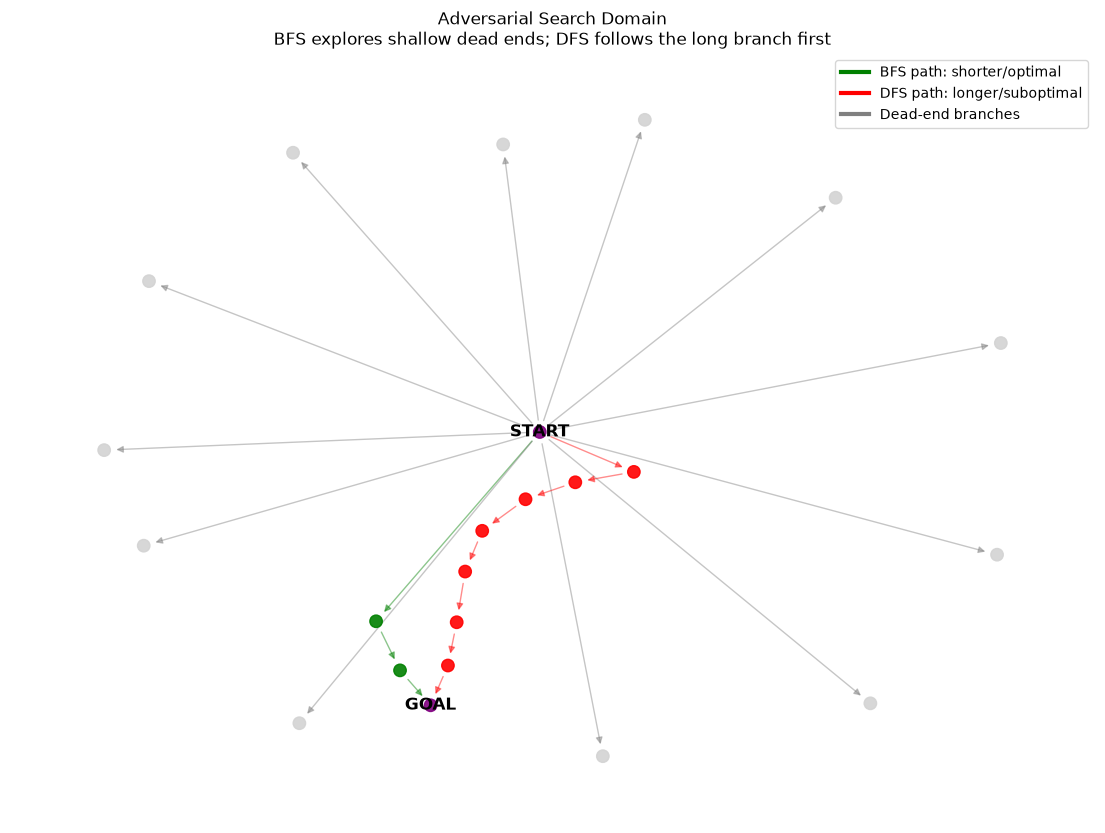

BFS: 18 states visited, 3 moves
DFS: 9 states visited, 8 moves


In [63]:
# Visualize the adversarial domain
adversarial_problem = return_adversarial_problem()

bfs_solution, bfs_visited, _ = breadth_first_search(adversarial_problem)
dfs_solution, dfs_visited, _ = depth_first_search(adversarial_problem)

graph = networkx.DiGraph()

# Build the graph from the domain definition
for state, children in adversarial_problem.children.items():
  for child in children:
      graph.add_edge(state, child)

bfs_states = set(bfs_solution.path)
dfs_states = set(dfs_solution.path)

# Color nodes according to the search path they belong to
node_colors = []
for node in graph.nodes:
  if node == adversarial_problem.goal:
      node_colors.append("purple")
  elif node in bfs_states and node in dfs_states:
      node_colors.append("purple")
  elif node in bfs_states:
      node_colors.append("green")
  elif node in dfs_states:
      node_colors.append("red")
  elif isinstance(node, tuple) and node[0] == "dead":
      node_colors.append("lightgray")
  else:
      node_colors.append("lightblue")

# Color edges according to BFS or DFS paths
bfs_edges = set(zip(bfs_solution.path, bfs_solution.path[1:]))
dfs_edges = set(zip(dfs_solution.path, dfs_solution.path[1:]))

edge_colors = []
for edge in graph.edges:
  if edge in bfs_edges and edge in dfs_edges:
      edge_colors.append("purple")
  elif edge in bfs_edges:
      edge_colors.append("green")
  elif edge in dfs_edges:
      edge_colors.append("red")
  else:
      edge_colors.append("gray")

positions = networkx.spring_layout(graph, seed=7)

plt.figure(figsize=(14, 10))

networkx.draw_networkx_edges(
  graph,
  positions,
  edge_color=edge_colors,
  arrows=True,
  arrowsize=10,
  alpha=0.45
)

networkx.draw_networkx_nodes(
  graph,
  positions,
  node_color=node_colors,
  node_size=80,
  alpha=0.9
)

networkx.draw_networkx_labels(
  graph,
  positions,
  labels={
      adversarial_problem.start: "START",
      adversarial_problem.goal: "GOAL"
  },
  font_size=12,
  font_weight="bold"
)

# Legend
plt.plot([], [], color="green", linewidth=3, label="BFS path: shorter/optimal")
plt.plot([], [], color="red", linewidth=3, label="DFS path: longer/suboptimal")
plt.plot([], [], color="gray", linewidth=3, label="Dead-end branches")

plt.legend()
plt.title(
  "Adversarial Search Domain\n"
  "BFS explores shallow dead ends; DFS follows the long branch first"
)
plt.axis("off")
plt.show()

print(
  "BFS: %d states visited, %d moves\n"
  "DFS: %d states visited, %d moves"
  % (
      bfs_visited,
      len(bfs_solution.path) - 1,
      dfs_visited,
      len(dfs_solution.path) - 1
  )
)

### <a name="time_spent"></a>4. Time Spent on Pset (5 points)

Please use [this form](https://forms.gle/QS7Raf1kvqgvCs9v5) to tell us how long you spent on this pset. After you submit the form, the form will give you a confirmation word. Please enter that confirmation word below to get an extra 5 points. 

In [64]:
form_confirmation_word = "Baymax"

In [65]:
# Run all tests
Grader.grade_output([TestPSet1], [locals()], "results.json")
Grader.print_test_results(
    "results.json")

Total score is 96/96.

Score for test_1_check_expanded_states (principles_of_autonomy.notebook_tests.pset_1.TestPSet1.test_1_check_expanded_states) is 25/25.

Score for test_2_puzzle_problem_expanded_nodes (principles_of_autonomy.notebook_tests.pset_1.TestPSet1.test_2_puzzle_problem_expanded_nodes) is 10/10.

Score for test_3_bfs (principles_of_autonomy.notebook_tests.pset_1.TestPSet1.test_3_bfs) is 27/27.
- Solution: 
+-----+
|  1 3|
|4 2 5|
|7 8 6|
+-----+

**

+-----+
|1   3|
|4 2 5|
|7 8 6|
+-----+

**

+-----+
|1 2 3|
|4   5|
|7 8 6|
+-----+

**

+-----+
|1 2 3|
|4 5  |
|7 8 6|
+-----+

**

+-----+
|1 2 3|
|4 5 6|
|7 8  |
+-----+

**



Score for test_4_dfs (principles_of_autonomy.notebook_tests.pset_1.TestPSet1.test_4_dfs) is 25/25.
- Solution: 
+-----+
|1 2 3|
|4 5 6|
|7   8|
+-----+

**

+-----+
|1 2 3|
|4 5 6|
|7 8  |
+-----+

**



Score for test_5_adversarial_bfs_vs_dfs (principles_of_autonomy.notebook_tests.pset_1.TestPSet1.test_5_adversarial_bfs_vs_dfs) is 4/4.
- BFS: 4 st